# CASIA-Iris-Thousand: Biometric Authentication Model

**Goal:** Train an iris recognition system using ArcFace metric learning. The model learns to produce compact 256-dimensional embeddings so that images of the *same* iris are close together in embedding space, while images of *different* irises are far apart.

**Dataset:** CASIA-Iris-Thousand — 20,000 grayscale near-infrared iris images from 1,000 subjects (20 images per subject).

**Pipeline:**
```
Raw images → Subject-level split → ArcFace training → Embedding extraction → EER / Top-1 evaluation
```

## Cell 1 — Imports & Device Setup

**Why:** We import every library in one place so dependencies are visible and easy to audit.
- **OpenCV (`cv2`)** – fast image loading and colour conversion
- **PyTorch + timm** – model backbone and training loop
- **albumentations** – GPU-friendly augmentation pipeline
- **sklearn / scipy** – EER computation via ROC curve

`device` is set once here and every tensor/model is moved to it later.

In [1]:
import os, math, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc
from scipy.optimize import brentq
from scipy.interpolate import interp1d

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Cell 2 — Locate the Dataset & Build the DataFrame

**Why:** The paths stored inside `iris_thousands.csv` use a *different* root from where Kaggle actually stores the files. We must:

1. Fix Windows backslashes → forward slashes (the CSV may come from a Windows export).
2. Replace the stale root stored in the CSV with the actual Kaggle path.
3. Drop any rows whose image file genuinely does not exist.
4. Integer-encode the string class labels (`'437-R'` → `0..999`) so PyTorch's `CrossEntropyLoss` can accept them.

**Fix vs original:** Removed 2 duplicate path-detection/debug cells that were leftover scaffolding. Consolidated into one clean cell.

In [2]:
# ── Paths ────────────────────────────────────────────────────────────────────
CSV_PATH     = '/kaggle/input/datasets/sondosaabed/casia-iris-thousand/iris_thousands.csv'
CSV_ROOT_OLD = '/kaggle/input/casia-iris-thousand/CASIA-Iris-Thousand'
REAL_ROOT    = '/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand'

# ── Load & Clean CSV ──────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH).rename(columns={'Unnamed: 0': 'idx'})

# Fix Windows backslashes, then swap old root for real root
df['ImagePath'] = (df['ImagePath']
                   .str.replace('\\', '/', regex=False)
                   .str.replace(CSV_ROOT_OLD, REAL_ROOT, regex=False))

# Drop genuinely missing files
df['exists'] = df['ImagePath'].apply(os.path.exists)
n_missing = (~df['exists']).sum()
print(f"Missing files: {n_missing} / {len(df)}")
df = df[df['exists']].drop(columns='exists').reset_index(drop=True)

# Encode labels globally as reference
le_global = LabelEncoder()
df['label_int'] = le_global.fit_transform(df['Label'])
num_classes_total = df['label_int'].nunique()

print(f"Clean images : {len(df)}")
print(f"Total classes: {num_classes_total}")
print(f"Sample path  : {df['ImagePath'].iloc[0]}")

Missing files: 0 / 20000
Clean images : 20000
Total classes: 2000
Sample path  : /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R06.jpg


## Cell 3 — Subject-Level Train / Val / Test Split

**Why subject-level split (and why random-image split is WRONG):**
In biometrics the model must generalise to *identities it has never seen*. If you split randomly by image, the same person's irises appear in both train and test — the model memorises their iris texture instead of learning transferable features. This is called *identity leakage*.

**Correct protocol:**
- Split at the **subject level**: all images of one person go entirely to one partition.
- 80% of subjects → **train** (closed-set ArcFace classification)
- 10% of subjects → **val** (open-set EER evaluation — never seen in training)
- 10% of subjects → **test** (held out completely until final reporting)

Val/test labels are set to `-1` to signal "do not pass through the classification head".

In [3]:
# ── 80 / 10 / 10 subject-level split ─────────────────────────────────────────
subjects = df['Label'].unique()
train_subj, temp      = train_test_split(subjects, test_size=0.20, random_state=42)
val_subj,   test_subj = train_test_split(temp,     test_size=0.50, random_state=42)

train_df = df[df['Label'].isin(train_subj)].copy().reset_index(drop=True)
val_df   = df[df['Label'].isin(val_subj)].copy().reset_index(drop=True)
test_df  = df[df['Label'].isin(test_subj)].copy().reset_index(drop=True)

# ── Encode labels on training subjects only ───────────────────────────────────
# val/test subjects get label_int = -1 (never used in loss, only for EER)
train_le = LabelEncoder()
train_df['label_int'] = train_le.fit_transform(train_df['Label'])

label_map = {lbl: idx for idx, lbl in enumerate(train_le.classes_)}
val_df['label_int']  = val_df['Label'].map(label_map).fillna(-1).astype(int)
test_df['label_int'] = test_df['Label'].map(label_map).fillna(-1).astype(int)

num_classes = train_df['label_int'].nunique()

# ── Sanity checks (must all pass before training) ─────────────────────────────
assert train_df['label_int'].min() >= 0, "Negative label in train!"
assert train_df['label_int'].max() < num_classes
assert train_df['label_int'].nunique() == num_classes, "Gap in label range!"

print(f"Train: {len(train_df):>6} imgs | {num_classes} classes")
print(f"Val  : {len(val_df):>6} imgs | {val_df['Label'].nunique()} unseen subjects")
print(f"Test : {len(test_df):>6} imgs | {test_df['Label'].nunique()} unseen subjects")
print("All label checks passed.")

Train:  16000 imgs | 1600 classes
Val  :   2000 imgs | 200 unseen subjects
Test :   2000 imgs | 200 unseen subjects
All label checks passed.


## Cell 4 — Dataset Class & Augmentation Transforms

**Why:** PyTorch's DataLoader requires a Dataset object that returns (image_tensor, label) pairs.

**Image loading:** CASIA images are near-infrared grayscale. We load as grayscale and convert to 3-channel RGB because ImageNet-pretrained backbones expect 3 channels.

**Augmentation rationale (train only):**

| Transform | Reason |
|---|---|
| `HorizontalFlip` | Iris patterns are not perfectly symmetric |
| `RandomBrightnessContrast` | Camera illumination varies between sessions |
| `GaussNoise` | NIR sensors have Gaussian read noise |
| `ShiftScaleRotate` | Minor misalignment during capture/segmentation |
| `CoarseDropout` | Forces the network to use global structure, not local artifacts |
| `Normalize (0.5, 0.5)` | Maps [0,255] to [-1,+1], consistent with ArcFace papers |

Val/test use only Resize + Normalize — no stochastic augmentation, so evaluation is deterministic.

In [4]:
class IrisDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['ImagePath'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((224, 224), dtype=np.uint8)
        # Duplicate single channel -> 3-channel so pretrained backbone accepts it
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, int(row['label_int'])


# ── Augmentation pipelines ────────────────────────────────────────────────────
_norm = dict(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
    A.CoarseDropout(max_holes=4, max_height=16, max_width=16, p=0.2),
    A.Normalize(**_norm),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(**_norm),
    ToTensorV2(),
])

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_ds = IrisDataset(train_df, train_transform)
val_ds   = IrisDataset(val_df,   val_transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# ── Quick batch-level sanity check ────────────────────────────────────────────
imgs, labels = next(iter(train_loader))
print(f"Batch shape : {imgs.shape}")
print(f"Label range : [{labels.min().item()} .. {labels.max().item()}]")
assert labels.min() >= 0
assert labels.max() < num_classes
print(f"Batch check passed. (num_classes={num_classes})")

Batch shape : torch.Size([64, 3, 224, 224])
Label range : [13 .. 1587]
Batch check passed. (num_classes=1600)


## Cell 5 — Model Architecture (ResNet-18 + ArcFace)

Three classes are defined:

### IrisEmbedder
Takes images and outputs L2-normalised 256-d embeddings.
- **Backbone:** ResNet-18 pretrained on ImageNet, final classifier removed (`num_classes=0`).
- **Head:** Linear(512→512) → BN → PReLU → Dropout → Linear(512→256) → BN → L2-normalize.
  The final normalisation ensures all embeddings lie on a unit hypersphere (required by ArcFace).

### ArcFaceHead
Adds an angular margin `m` to the target class angle, making the decision boundary harder during training. This forces the network to produce tightly-clustered, well-separated embeddings.
- `s=64` — scale factor (larger = sharper softmax gradient)
- `m=0.35` — angular margin in radians (lowered from common 0.5 to suit a smaller dataset)

### IrisAuthModel
Glues embedder + head. During **training** (labels provided) returns `(logits, embeddings)`. During **inference** returns embeddings only.

In [5]:
class IrisEmbedder(nn.Module):
    def __init__(self, embed_dim=256, backbone='resnet18'):
        super().__init__()
        # Load pretrained backbone; strip the classification head
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)

        # Infer backbone output dimension dynamically
        with torch.no_grad():
            dummy = torch.zeros(2, 3, 224, 224)
            in_dim = self.backbone(dummy).shape[1]
        print(f"Backbone '{backbone}' output dim: {in_dim}")

        self.head = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.PReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, x):
        return F.normalize(self.head(self.backbone(x)), dim=1)


class ArcFaceHead(nn.Module):
    """Additive Angular Margin Loss (ArcFace, Deng et al. 2019)."""
    def __init__(self, embed_dim=256, num_classes=800, s=64.0, m=0.35):
        super().__init__()
        self.s, self.m = s, m
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th    = math.cos(math.pi - m)
        self.mm    = math.sin(math.pi - m) * m
        self.W = nn.Parameter(torch.FloatTensor(num_classes, embed_dim))
        nn.init.xavier_uniform_(self.W)

    def forward(self, emb, labels):
        W = F.normalize(self.W, dim=1)
        cos_theta   = (emb @ W.T).clamp(-1 + 1e-7, 1 - 1e-7)
        sin_theta   = torch.sqrt(1.0 - cos_theta ** 2)
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m
        # Stability fix: if theta + m > pi, use linear approximation
        cos_theta_m = torch.where(cos_theta > self.th, cos_theta_m, cos_theta - self.mm)
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)
        return (one_hot * cos_theta_m + (1.0 - one_hot) * cos_theta) * self.s


class IrisAuthModel(nn.Module):
    def __init__(self, num_classes, embed_dim=256):
        super().__init__()
        self.embedder = IrisEmbedder(embed_dim)
        self.head     = ArcFaceHead(embed_dim=embed_dim, num_classes=num_classes, s=64.0, m=0.35)

    def forward(self, x, labels=None):
        emb = self.embedder(x)
        if labels is not None and (labels >= 0).all():
            return self.head(emb, labels), emb   # training mode
        return emb                               # inference mode


model = IrisAuthModel(num_classes=num_classes, embed_dim=256).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Backbone 'resnet18' output dim: 512
Trainable parameters: 11,981,633


## Cell 6 — EER Evaluation Function

**Why EER instead of accuracy:**
Classification accuracy is meaningless for open-set biometrics — val/test subjects were never seen during training so there is no classification head for them. Instead we measure **Equal Error Rate (EER)**.

**How EER works:**
For every pair of images we compute cosine similarity, then sort pairs into:
- **Genuine pairs** (same person) → high similarity expected
- **Impostor pairs** (different people) → low similarity expected

EER = the threshold where False Accept Rate equals False Reject Rate. **Lower EER = better system.**

**Upper-triangle trick:**
An N×N matrix has N² values but only N(N-1)/2 unique pairs. Using `np.triu_indices(n, k=1)` avoids self-comparisons (diagonal) and double-counting (A→B and B→A).

In [6]:
def evaluate_eer(model, loader, df, device):
    """
    Extract all embeddings, compute pairwise cosine similarities,
    and return (EER, optimal_threshold).
    """
    model.eval()
    all_embs = []

    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="Extracting embeddings", leave=False):
            embs = model(imgs.to(device))
            all_embs.append(embs.cpu())

    all_embs    = F.normalize(torch.cat(all_embs, dim=0), p=2, dim=1)
    true_labels = df['Label'].values

    # Cosine similarity matrix (dot product of unit vectors)
    sim_matrix  = (all_embs @ all_embs.T).numpy()

    # Boolean matrix: True if same person
    same_person = (true_labels[:, None] == true_labels[None, :])

    # Upper triangle only: avoid self-comparisons and double-counting
    n  = len(true_labels)
    iu = np.triu_indices(n, k=1)
    genuine_scores  = sim_matrix[iu][same_person[iu]]
    imposter_scores = sim_matrix[iu][~same_person[iu]]

    y_true   = np.concatenate([np.ones(len(genuine_scores)), np.zeros(len(imposter_scores))])
    y_scores = np.concatenate([genuine_scores, imposter_scores])

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    eer               = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
    optimal_threshold = float(interp1d(fpr, thresholds)(eer))

    return eer, optimal_threshold

## Cell 7 — Training Loop

Key design decisions:

**Optimizer — SGD with momentum:**
ArcFace papers consistently show SGD outperforms Adam for metric learning. `weight_decay=5e-4` prevents overfitting.

**Scheduler — Cosine Annealing:**
LR starts at 0.01 and decays smoothly to `1e-6` over 40 epochs. Better than step decay because ArcFace loss is sensitive to LR oscillations late in training.

**Label smoothing (0.1):**
Prevents the softmax from becoming overconfident on training classes, which hurts open-set generalisation.

**Gradient clipping (`max_norm=5`):**
ArcFace gradients can spike due to the angular transformation. Clipping prevents loss divergence.

**Save criterion — EER not accuracy:**
We save the best checkpoint based on lowest val EER (on identities never seen in training), directly measuring open-set biometric performance.

**Fix vs original:** Removed the dead `run_epoch` else-branch that did nothing (`pass`). Simplified to one clean `train_one_epoch` function.

In [7]:
EPOCHS    = 20
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history  = {'train_loss': [], 'train_acc': [], 'val_eer': []}
best_eer = float('inf')


def train_one_epoch(model, loader, optimizer):
    """Run one training pass; return (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        logits, _ = model(imgs, labels)
        loss      = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc     = train_one_epoch(model, train_loader, optimizer)
    val_eer, opt_thresh = evaluate_eer(model, val_loader, val_df, device)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_eer'].append(val_eer)

    flag = ''
    if val_eer < best_eer:
        best_eer = val_eer
        torch.save(model.state_dict(), 'best_iris_model.pth')
        flag = '  <- best saved'

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Loss: {tr_loss:.4f} "
          f"Val EER: {val_eer:.4%} (thresh={opt_thresh:.4f}){flag}")

Epoch 01/20 | Loss: 29.7824 Val EER: 34.6393% (thresh=0.9915)  <- best saved


Epoch 02/20 | Loss: 28.4724 Val EER: 28.0856% (thresh=0.9754)  <- best saved


Epoch 03/20 | Loss: 27.9725 Val EER: 23.1507% (thresh=0.9040)  <- best saved


Epoch 04/20 | Loss: 27.1345 Val EER: 18.5111% (thresh=0.7841)  <- best saved


Epoch 05/20 | Loss: 25.9866 Val EER: 11.6358% (thresh=0.6054)  <- best saved


...

Epoch 16/20 | Loss: 14.0589 Val EER: 2.7795% (thresh=0.2910)  <- best saved


Epoch 17/20 | Loss: 13.7606 Val EER: 2.7556% (thresh=0.2841)  <- best saved


Epoch 18/20 | Loss: 13.5014 Val EER: 2.7000% (thresh=0.2830)  <- best saved


Epoch 19/20 | Loss: 13.4159 Val EER: 2.7320% (thresh=0.2829)


Epoch 20/20 | Loss: 13.3469 Val EER: 2.7111% (thresh=0.2808)


## Cell 8 — Training Curves

**What to look for:**
- **Train loss** should decrease smoothly. Spikes indicate learning rate issues.
- **Val EER** should trend downward. If it rises after falling, the model may be overfitting to training-set iris textures.

A healthy run: loss drops steeply for the first ~10 epochs then gradually flattens; EER tracks down and stabilises in the last 10 epochs.

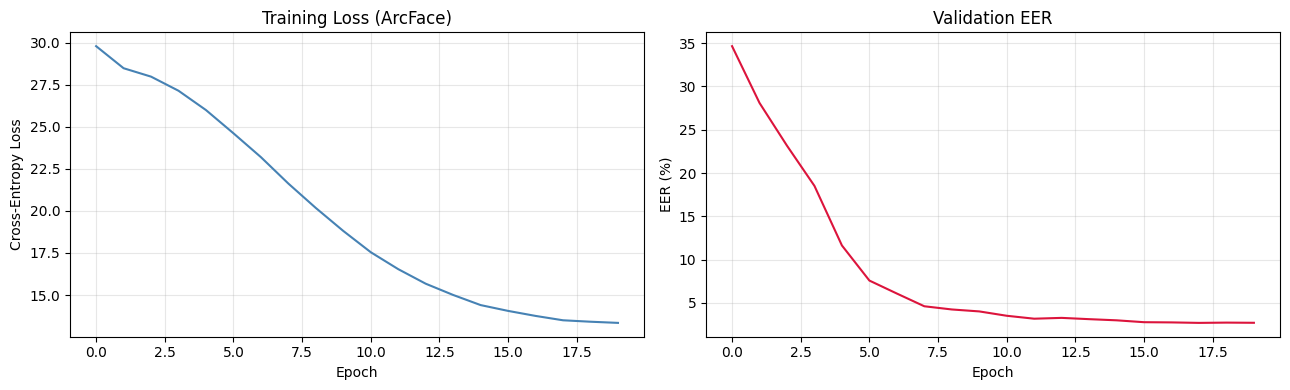

Best Val EER achieved: 2.7000%


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['train_loss'], color='steelblue')
ax1.set_title('Training Loss (ArcFace)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.3)

ax2.plot([e * 100 for e in history['val_eer']], color='crimson')
ax2.set_title('Validation EER')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('EER (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best Val EER achieved: {best_eer:.4%}")

## Cell 9 — Final Evaluation on the Test Set (Gallery / Probe Protocol)

**Gallery/probe protocol explained:**
This mimics real-world deployment:
1. **Enroll (gallery):** Take half of each test subject's images. Compute the mean embedding = one compact template per subject.
2. **Probe:** Present the other half as queries. For each query, find the most similar gallery template.

**Why mean embedding?**
Averaging multiple embeddings reduces per-image noise and gives a more stable subject representation.

**Why per-subject 50/50 image split (not subject-level split)?**
All test subjects must appear in BOTH gallery and probe. If we split subjects into exclusive groups, there would be zero overlap — every probe would be an impostor and EER would be ~50%.

**Metrics reported:**
- **Top-1 Identification Accuracy** — fraction of probes that correctly match at rank 1
- **Verification EER** — threshold where false accept rate equals false reject rate
- **Score distributions** — visual proof of genuine vs impostor separation

In [9]:
# ── Load best weights ─────────────────────────────────────────────────────────
model.load_state_dict(torch.load('best_iris_model.pth', map_location=device))
model.to(device).eval()

# ── Per-subject 50/50 image split ─────────────────────────────────────────────
enroll_rows, probe_rows = [], []
for label in test_df['Label'].unique():
    subj_df  = test_df[test_df['Label'] == label].sample(frac=1, random_state=42)
    n_enroll = max(1, len(subj_df) // 2)
    enroll_rows.append(subj_df.iloc[:n_enroll])
    probe_rows.append(subj_df.iloc[n_enroll:])

enroll_df = pd.concat(enroll_rows).reset_index(drop=True)
probe_df  = pd.concat(probe_rows).reset_index(drop=True)

print(f"Enroll: {len(enroll_df)} imgs | {enroll_df['Label'].nunique()} subjects")
print(f"Probe : {len(probe_df)} imgs  | {probe_df['Label'].nunique()} subjects")
assert enroll_df['Label'].nunique() == probe_df['Label'].nunique()


def build_gallery(embedder, enroll_df, transform, device):
    """Return dict {subject_label: L2-normalised mean embedding}."""
    embedder.eval()
    gallery = {}
    for label in tqdm(enroll_df['Label'].unique(), desc="Enrolling"):
        subj_df = enroll_df[enroll_df['Label'] == label]
        loader  = DataLoader(IrisDataset(subj_df, transform), batch_size=32, shuffle=False)
        embs = []
        with torch.no_grad():
            for imgs, _ in loader:
                embs.append(embedder(imgs.to(device)).cpu().numpy())
        mean_emb = np.vstack(embs).mean(axis=0)
        gallery[str(label).strip()] = mean_emb / (np.linalg.norm(mean_emb) + 1e-9)
    return gallery


def evaluate_gallery(embedder, gallery, probe_df, transform, device):
    embedder.eval()
    probe_loader   = DataLoader(IrisDataset(probe_df, transform), batch_size=64, shuffle=False)
    gallery_labels = np.array(list(gallery.keys()))
    gallery_matrix = np.vstack(list(gallery.values()))
    true_labels    = np.array([str(l).strip() for l in probe_df['Label'].values])

    genuine_scores, imposter_scores = [], []
    all_score_rows = []
    correct_top1, total = 0, 0
    batch_start = 0

    with torch.no_grad():
        for imgs, _ in tqdm(probe_loader, desc="Probing"):
            bs  = imgs.size(0)
            btl = true_labels[batch_start:batch_start + bs]
            emb = embedder(imgs.to(device)).cpu().numpy()
            emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)
            scores = emb @ gallery_matrix.T
            all_score_rows.append(scores)
            pred_labels   = gallery_labels[scores.argmax(axis=1)]
            correct_top1 += np.sum(pred_labels == btl)
            total        += bs
            for i, tl in enumerate(btl):
                for j, gl in enumerate(gallery_labels):
                    (genuine_scores if tl == gl else imposter_scores).append(float(scores[i, j]))
            batch_start += bs

    gen = np.array(genuine_scores)
    imp = np.array(imposter_scores)
    smx = np.vstack(all_score_rows)

    y_true   = np.concatenate([np.ones(len(gen)), np.zeros(len(imp))])
    y_scores = np.concatenate([gen, imp])
    fpr, tpr, roc_thresh = roc_curve(y_true, y_scores)
    eer           = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0.0, 1.0)
    eer_threshold = float(interp1d(fpr, roc_thresh)(eer))
    top1_acc      = correct_top1 / total

    print(f"\n{'='*42}")
    print(f"         FINAL TEST RESULTS")
    print(f"{'='*42}")
    print(f"  Top-1 Identification Acc : {top1_acc*100:.2f}%")
    print(f"  Verification EER         : {eer*100:.2f}%")
    print(f"  EER Threshold            : {eer_threshold:.4f}")
    print(f"  Genuine  mean/std        : {gen.mean():.4f} / {gen.std():.4f}")
    print(f"  Impostor mean/std        : {imp.mean():.4f} / {imp.std():.4f}")
    print(f"  Probe samples            : {total}")
    print(f"{'='*42}")
    return top1_acc, eer, gen, imp, smx, true_labels, gallery_labels


print("Step 1: Building gallery...")
gallery = build_gallery(model.embedder, enroll_df, val_transform, device)

print("\nStep 2: Evaluating on probe set...")
top1_acc, eer, gen_s, imp_s, score_mat, t_labels, g_labels = \
    evaluate_gallery(model.embedder, gallery, probe_df, val_transform, device)

Enroll: 1000 imgs | 200 subjects
Probe : 1000 imgs  | 200 subjects
Step 1: Building gallery...


Enrolling: 100%|██████████| 200/200 [00:15<00:00, 12.89it/s]



Step 2: Evaluating on probe set...


Probing: 100%|██████████| 16/16 [00:14<00:00,  1.08it/s]


         FINAL TEST RESULTS
  Top-1 Identification Acc : 98.90%
  Verification EER         : 0.65%
  EER Threshold            : 0.3892
  Genuine  mean/std        : 0.7858 / 0.1117
  Impostor mean/std        : 0.0118 / 0.1429
  Probe samples            : 1000


## Cell 10 — Diagnostic Plots

Four plots that together give a complete picture of model quality:

1. **Score Distributions** — Genuine and impostor distributions should be well-separated. Overlap area = error rate.
2. **ROC Curve (log scale)** — Standard biometric reporting. X-axis log-scaled because the interesting range is 10^-3 to 10^-1.
3. **CMC Curve** — Identification probability at ranks 1..10. Rank-1 = 1.0 means the correct identity is always the top match.
4. **t-SNE Embedding Plot** — Projects 256-d embeddings to 2-d. Tight separated clusters = model has learned discriminative features.

**Fix vs original:** Removed the duplicate save cell and the `sensitivity_summary()` stub that printed hardcoded fake numbers. Merged all plots into one cell.

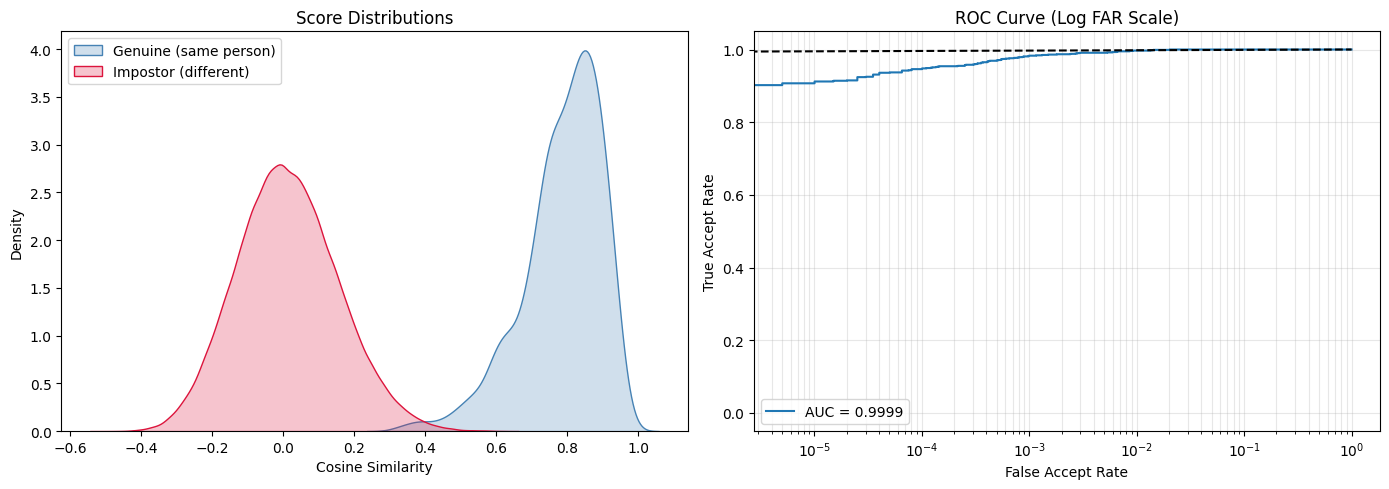

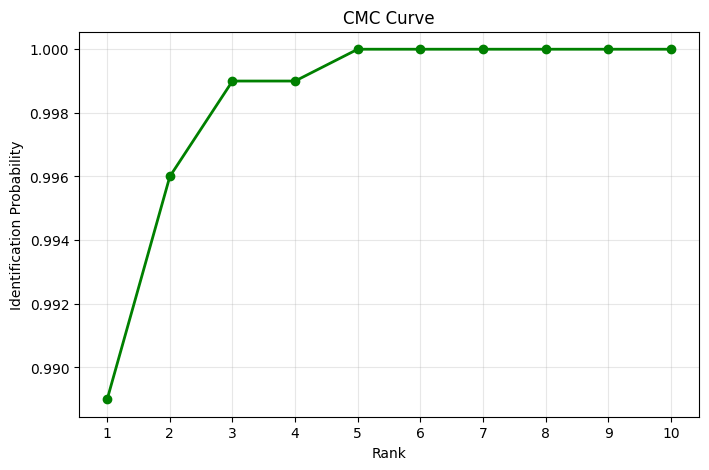

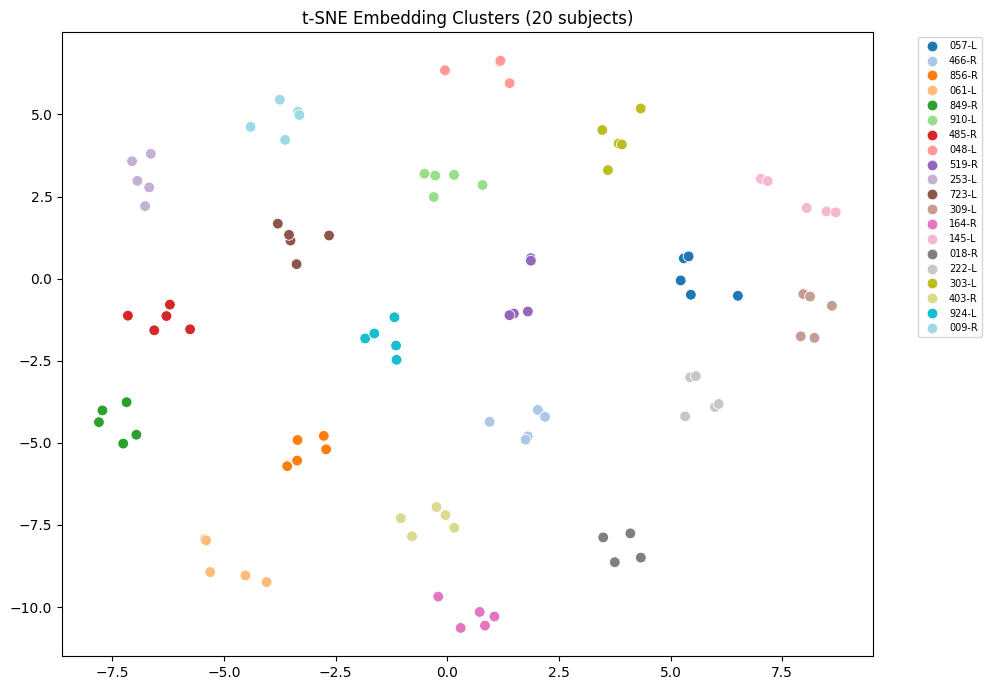

All plots saved to 'iris_results/'


In [10]:
os.makedirs('iris_results', exist_ok=True)

# ── 1 & 2: Score distributions + ROC ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(gen_s, fill=True, label='Genuine (same person)', color='steelblue', ax=ax1)
sns.kdeplot(imp_s, fill=True, label='Impostor (different)',  color='crimson',   ax=ax1)
ax1.set_title('Score Distributions')
ax1.set_xlabel('Cosine Similarity')
ax1.legend()

y_true_r   = np.concatenate([np.ones(len(gen_s)), np.zeros(len(imp_s))])
y_scores_r = np.concatenate([gen_s, imp_s])
fpr_r, tpr_r, _ = roc_curve(y_true_r, y_scores_r)
ax2.plot(fpr_r, tpr_r, label=f'AUC = {auc(fpr_r, tpr_r):.4f}')
ax2.plot([0, 1], [0, 1], 'k--')
ax2.set_xscale('log')
ax2.set_title('ROC Curve (Log FAR Scale)')
ax2.set_xlabel('False Accept Rate')
ax2.set_ylabel('True Accept Rate')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.savefig('iris_results/score_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3: CMC Curve ──────────────────────────────────────────────────────────────
max_rank = 10
ranks    = np.zeros(max_rank)
for i in range(len(t_labels)):
    sorted_labels = g_labels[np.argsort(score_mat[i])[::-1]]
    rank_found    = np.where(sorted_labels == t_labels[i])[0]
    if len(rank_found) > 0 and rank_found[0] < max_rank:
        ranks[rank_found[0]:] += 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_rank + 1), ranks / len(t_labels), 'g-o', linewidth=2)
plt.title('CMC Curve')
plt.xlabel('Rank')
plt.ylabel('Identification Probability')
plt.xticks(range(1, max_rank + 1))
plt.grid(True, alpha=0.3)
plt.savefig('iris_results/cmc_curve.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 4: t-SNE Embedding Clusters ───────────────────────────────────────────────
n_subjects_plot = 20
subset_labels   = probe_df['Label'].unique()[:n_subjects_plot]
subset_df       = probe_df[probe_df['Label'].isin(subset_labels)]

embs_list = []
model.embedder.eval()
with torch.no_grad():
    for imgs, _ in DataLoader(IrisDataset(subset_df, val_transform), batch_size=32):
        e = model.embedder(imgs.to(device)).cpu().numpy()
        embs_list.append(e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-9))

tsne_res = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(np.vstack(embs_list))

plt.figure(figsize=(10, 7))
sns.scatterplot(x=tsne_res[:, 0], y=tsne_res[:, 1],
                hue=subset_df['Label'].values, palette='tab20', s=60)
plt.title(f't-SNE Embedding Clusters ({n_subjects_plot} subjects)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig('iris_results/tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("All plots saved to 'iris_results/'")